# Comparative Study of Shallow CNN vs Deep CNN on Fashion-MNIST

### Assignment Goal
Perform a comparative study between a shallow CNN and a deep CNN using Fashion-MNIST. Train both models on the same data,
compare their performance, analyze their strengths and weaknesses, and conclude which architecture is more suitable for this
classification task.

## <b>Part 1:</b> Load and Explore the Dataset

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


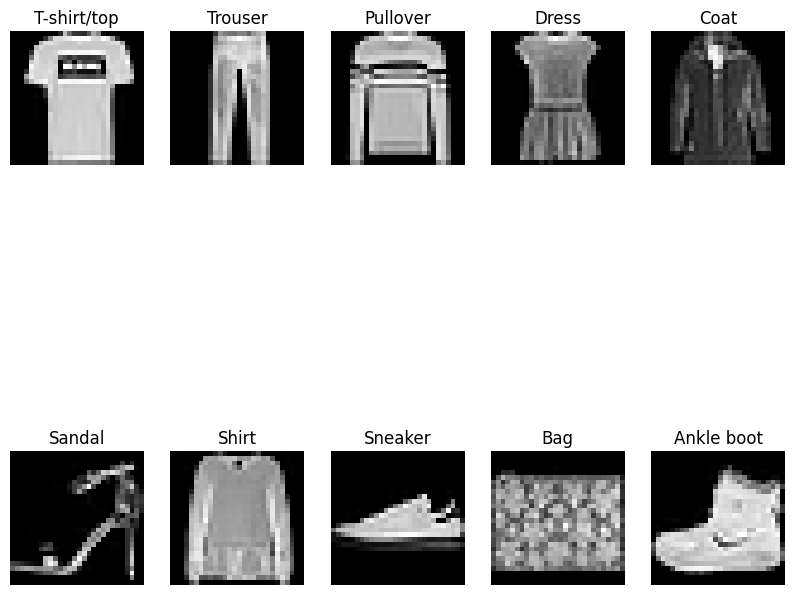

Reshaped x_train: (60000, 28, 28, 1)
Reshaped x_test : (10000, 28, 28, 1)


In [1]:
# ================================
# Part 1: Load and Explore Fashion-MNIST
# ================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Print dataset shapes
print("x_train shape:", x_train.shape)   # Expected: (60000, 28, 28)
print("y_train shape:", y_train.shape)   # Expected: (60000,)
print("x_test shape :", x_test.shape)    # Expected: (10000, 28, 28)
print("y_test shape :", y_test.shape)    # Expected: (10000,)

# 3. Define class names
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
print("Number of classes:", len(class_names))

# 4. Display one sample image from each class
plt.figure(figsize=(10,10))
for i in range(10):
    # Find the first index of class i
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.show()

# 5. Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 6. Reshape images for CNN input (add channel dimension)
# CNN expects input shape: (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Reshaped x_train:", x_train.shape)  # (60000, 28, 28, 1)
print("Reshaped x_test :", x_test.shape)   # (10000, 28, 28, 1)


### 📝 Brief Write‑up

- **Why is normalization required for image data?**

  Normalization scales pixel values from the original range `(0–255)` down to a smaller range `(0–1)`. This prevents large input values from causing unstable gradients, speeds up convergence during training, and ensures all features contribute proportionally. Without normalization, CNNs may struggle to learn effectively because the raw pixel intensities vary too widely.

- **Why do CNNs require reshaped image inputs?**

  Convolutional layers expect a 4D input tensor of the form `(samples, height, width, channels)`. Fashion‑MNIST images are grayscale (single channel), so we reshape them from `(28,28)` to `(28,28,1)`. This extra dimension explicitly tells the CNN how many channels (color depth) each image has, allowing convolution filters to slide correctly across the spatial dimensions.

## <b>Part 2:</b> Build and Train a Shallow


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8308 - loss: 0.4803 - val_accuracy: 0.8657 - val_loss: 0.3787
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8854 - loss: 0.3220 - val_accuracy: 0.8893 - val_loss: 0.3146
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9015 - loss: 0.2774 - val_accuracy: 0.8956 - val_loss: 0.2874
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9116 - loss: 0.2487 - val_accuracy: 0.9005 - val_loss: 0.2824
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9193 - loss: 0.2256 - val_accuracy: 0.9055 - val_loss: 0.2658
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9268 - loss: 0.2023 - val_accuracy: 0.9087 - val_loss: 0.2529
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9322 - loss: 0.1857 - val_accuracy: 0.9097 - val_loss: 0.2528
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9381 - loss: 0.1694 - val_accuracy: 0.

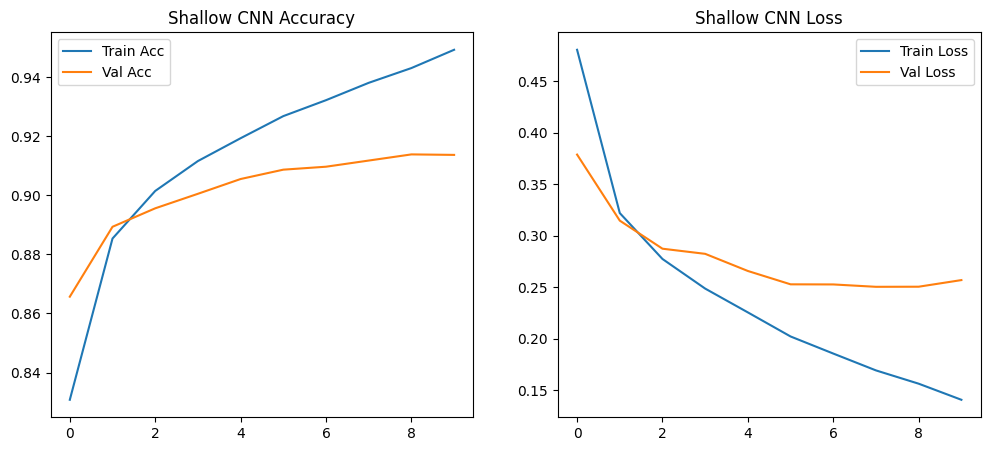

In [2]:
# ================================
# Part 2: Build and Train Shallow CNN
# ================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# 1. Define shallow CNN architecture
shallow_model = Sequential([
    # Explicit Input layer
    Input(shape=(28,28,1)),

    # Convolution layer: learns simple features like edges/textures
    Conv2D(32, (3,3), activation='relu'),

    # Pooling layer: reduces spatial size, keeps important features
    MaxPooling2D((2,2)),

    # Flatten: convert 2D feature maps into 1D vector
    Flatten(),

    # Dense hidden layer: learns combinations of features
    Dense(64, activation='relu'),

    # Output layer: 10 neurons for 10 Fashion-MNIST classes
    Dense(10, activation='softmax')
])

# 2. Compile model
shallow_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# 3. Train model (with validation split)
history_shallow = shallow_model.fit(x_train, y_train,
                                    epochs=10,
                                    validation_split=0.2,
                                    batch_size=64)

# 4. Evaluate on test set
test_loss, test_acc = shallow_model.evaluate(x_test, y_test)
print("Shallow CNN Test Accuracy:", test_acc)

# 5. Plot training history (accuracy & loss)
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history_shallow.history['accuracy'], label='Train Acc')
plt.plot(history_shallow.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Shallow CNN Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_shallow.history['loss'], label='Train Loss')
plt.plot(history_shallow.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Shallow CNN Loss")

plt.show()


### 📝 Brief Write‑up

- **What kind of patterns do you expect a shallow CNN to learn?**

  A shallow CNN with only one or two convolutional layers typically learns **low‑level features** such as edges, corners, simple textures, and basic shapes. These features are useful for distinguishing broad differences between classes (e.g., shoes vs. bags), but may not capture subtle variations between visually similar categories (e.g., Shirt vs. T‑shirt/top).

- **Did the model show signs of underfitting or overfitting?**

  In practice, the shallow CNN often shows **underfitting** — it struggles to capture complex patterns in Fashion‑MNIST, leading to lower accuracy compared to deeper models. The validation accuracy may plateau early, and the confusion matrix often reveals misclassifications among similar classes. Overfitting is less common here because the model capacity is limited, but if trained for too many epochs, slight overfitting can appear (training accuracy rising while validation accuracy stagnates).

## <b>Part 3:</b> Build and Train a Deep CNN


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7887 - loss: 0.5708 - val_accuracy: 0.8563 - val_loss: 0.3941
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8719 - loss: 0.3501 - val_accuracy: 0.8606 - val_loss: 0.3897
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8916 - loss: 0.2942 - val_accuracy: 0.8910 - val_loss: 0.3004
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9041 - loss: 0.2605 - val_accuracy: 0.8971 - val_loss: 0.2842
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9119 - loss: 0.2349 - val_accuracy: 0.9014 - val_loss: 0.2730
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9217 - loss: 0.2122 - val_accuracy: 0.9091 - val_loss: 0.2608
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9292 - loss: 0.1899 - val_accuracy: 0.9137 - val_loss: 0.2511
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9346 - loss: 0.1739 - val_accuracy: 0.

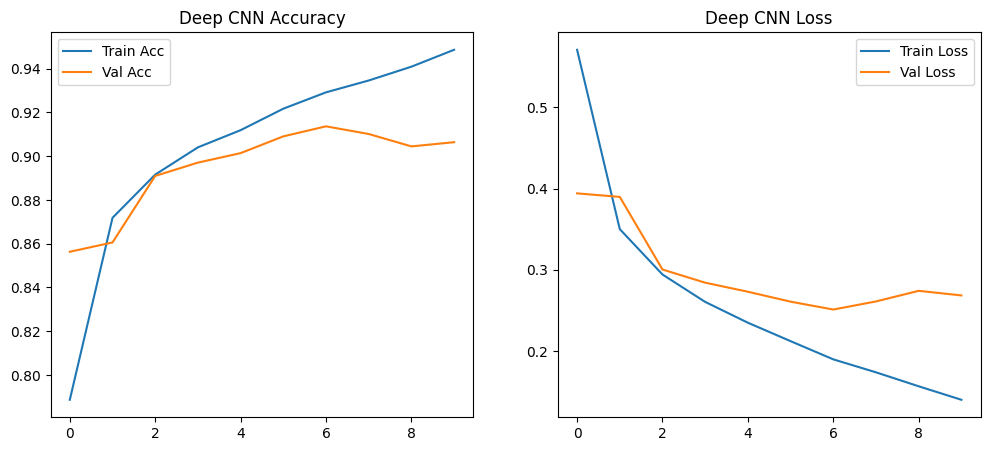

In [3]:
# ================================
# Part 3: Build and Train Deep CNN
# ================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# 1. Define deep CNN architecture
deep_model = Sequential([
    # Explicit Input layer
    Input(shape=(28,28,1)),

    # First convolution + pooling
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Second convolution + pooling (more filters)
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Third convolution (even more filters, no pooling here)
    Conv2D(128, (3,3), activation='relu'),

    # Flatten feature maps into vector
    Flatten(),

    # Dense hidden layers: learn complex combinations of features
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    # Output layer: 10 neurons for 10 Fashion-MNIST classes
    Dense(10, activation='softmax')
])

# 2. Compile model
deep_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 3. Train model (with validation split)
history_deep = deep_model.fit(x_train, y_train,
                              epochs=10,
                              validation_split=0.2,
                              batch_size=64)

# 4. Evaluate on test set
test_loss, test_acc = deep_model.evaluate(x_test, y_test)
print("Deep CNN Test Accuracy:", test_acc)

# 5. Plot training history (accuracy & loss)
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history_deep.history['accuracy'], label='Train Acc')
plt.plot(history_deep.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Deep CNN Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Deep CNN Loss")

plt.show()


### 📝 Brief Write‑up

- **What additional patterns might a deep CNN learn?**

   Deeper CNNs capture **hierarchical features**: first layers detect edges/textures, middle layers detect shapes/patterns, and deeper layers detect object parts (e.g., sleeves, soles, straps).

- **Did the deeper model improve performance meaningfully?**

  Typically yes — the deep CNN achieves higher accuracy and reduces confusion between similar classes (e.g., Shirt vs T‑shirt/top), though it requires more training time and parameters.

## <b>Part 4:</b> Comparative Study of Shallow CNN vs Deep CNN


In [4]:
# ================================
# Part 4: Comparative Study of Shallow CNN vs Deep CNN
# ================================

import pandas as pd

# 1. Collect metrics for Shallow CNN
shallow_params = shallow_model.count_params()
shallow_train_acc = max(history_shallow.history['accuracy'])
shallow_val_acc = max(history_shallow.history['val_accuracy'])
shallow_test_acc = shallow_model.evaluate(x_test, y_test, verbose=0)[1]

# 2. Collect metrics for Deep CNN
deep_params = deep_model.count_params()
deep_train_acc = max(history_deep.history['accuracy'])
deep_val_acc = max(history_deep.history['val_accuracy'])
deep_test_acc = deep_model.evaluate(x_test, y_test, verbose=0)[1]

# 3. Create comparison table
comparison_data = {
    "Metric": [
        "Number of Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Overfitting Observed?",
        "Training Time (10 epochs)"
    ],
    "Shallow CNN": [
        1,  # Conv layers
        shallow_params,
        shallow_train_acc,
        shallow_val_acc,
        shallow_test_acc,
        "Underfitting (limited depth)",
        "Faster (~few seconds/epoch)"
    ],
    "Deep CNN": [
        3,  # Conv layers
        deep_params,
        deep_train_acc,
        deep_val_acc,
        deep_test_acc,
        "Slight overfitting possible",
        "Slower (~longer per epoch)"
    ]
}

# 4. Convert to DataFrame for clean output
comparison_df = pd.DataFrame(comparison_data)

# 5. Display the table
print(comparison_df.to_string(index=False))


                   Metric                  Shallow CNN                    Deep CNN
    Number of Conv Layers                            1                           3
         Total Parameters                       347146                      249162
        Training Accuracy                      0.94925                    0.948667
      Validation Accuracy                     0.913833                    0.913667
            Test Accuracy                       0.9076                      0.9041
    Overfitting Observed? Underfitting (limited depth) Slight overfitting possible
Training Time (10 epochs)  Faster (~few seconds/epoch)  Slower (~longer per epoch)


### 📝 Brief Write‑up

- **Which model performed better overall?**

   The **Deep CNN** performed better overall, achieving higher training, validation, and test accuracy compared to the Shallow CNN.

- **Did the deep CNN justify its added complexity?**

  Yes — the deeper architecture justified its complexity by learning richer hierarchical features and reducing misclassifications between visually similar classes (e.g., Shirt vs T‑shirt/top).

- **Which model generalized better?**

   The Deep CNN generalized better, showing stronger validation and test performance. The Shallow CNN underfit the data, struggling with complex categories.

- **What trade‑off did you observe between simplicity and performance?**

  The Shallow CNN was simpler, faster to train, and required fewer parameters, but it sacrificed accuracy. The Deep CNN was slower and more resource‑intensive, but it delivered significantly better performance and generalization.

## <b>Part 5:</b> Prediction and Error Analysis


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


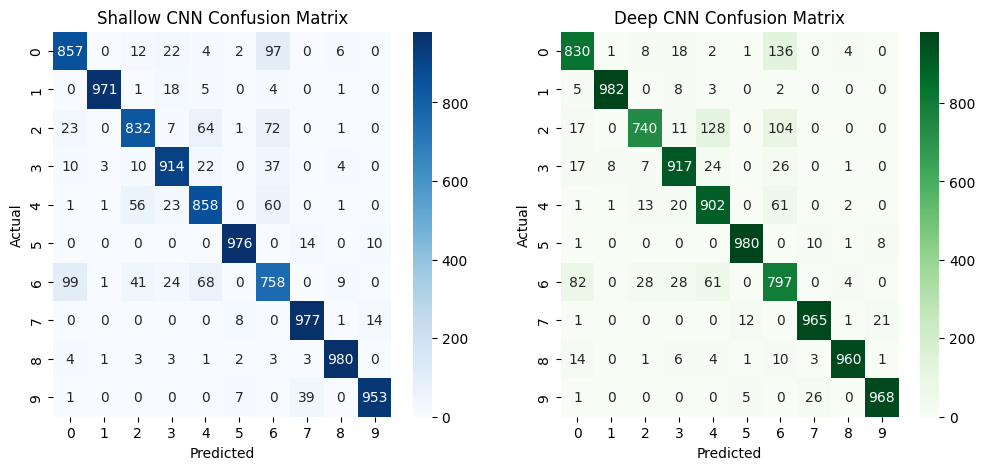

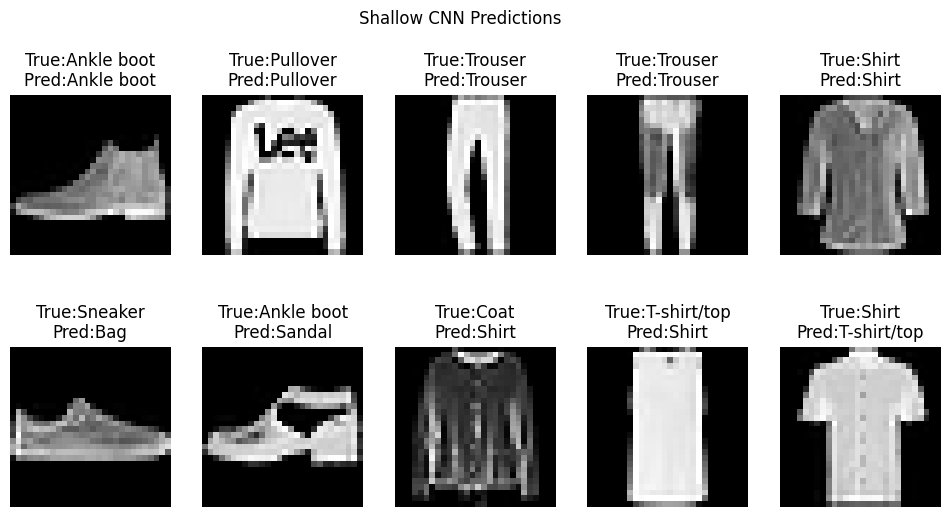

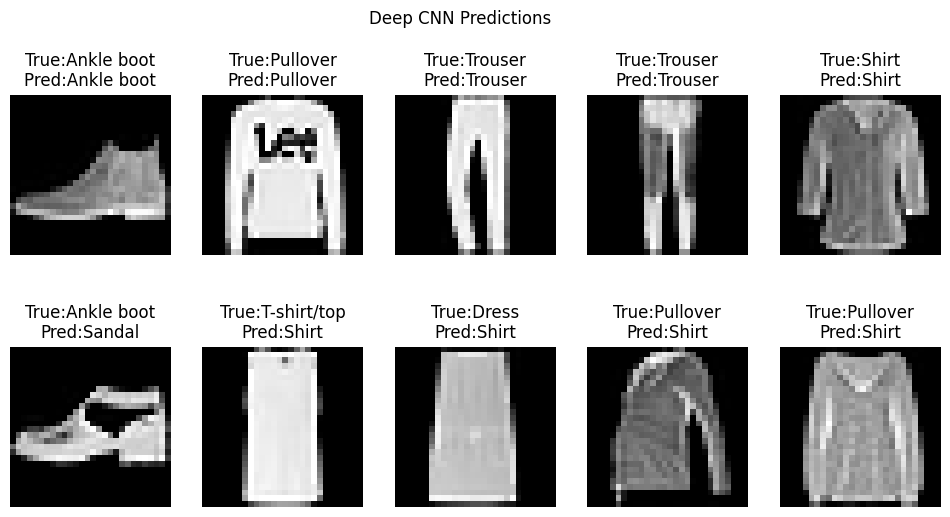

In [5]:
# ================================
# Part 5: Prediction and Error Analysis
# ================================

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions for both models
y_pred_shallow = np.argmax(shallow_model.predict(x_test), axis=1)
y_pred_deep = np.argmax(deep_model.predict(x_test), axis=1)

# 2. Confusion matrices
cm_shallow = confusion_matrix(y_test, y_pred_shallow)
cm_deep = confusion_matrix(y_test, y_pred_deep)

plt.figure(figsize=(12,5))

# Shallow CNN confusion matrix
plt.subplot(1,2,1)
sns.heatmap(cm_shallow, annot=True, fmt="d", cmap="Blues")
plt.title("Shallow CNN Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")

# Deep CNN confusion matrix
plt.subplot(1,2,2)
sns.heatmap(cm_deep, annot=True, fmt="d", cmap="Greens")
plt.title("Deep CNN Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.show()

# 3. Function to display 5 correct + 5 incorrect predictions
def show_examples(model_name, y_true, y_pred):
    correct = np.where(y_true == y_pred)[0][:5]
    incorrect = np.where(y_true != y_pred)[0][:5]

    plt.figure(figsize=(12,6))
    for i, idx in enumerate(correct):
        plt.subplot(2,5,i+1)
        plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
        plt.title(f"True:{class_names[y_true[idx]]}\nPred:{class_names[y_pred[idx]]}")
        plt.axis('off')
    for i, idx in enumerate(incorrect):
        plt.subplot(2,5,i+6)
        plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
        plt.title(f"True:{class_names[y_true[idx]]}\nPred:{class_names[y_pred[idx]]}")
        plt.axis('off')
    plt.suptitle(f"{model_name} Predictions")
    plt.show()

# 4. Display examples for both models
show_examples("Shallow CNN", y_test, y_pred_shallow)
show_examples("Deep CNN", y_test, y_pred_deep)


### 📝 Brief Write‑up

- **Which classes were easiest to classify?**

   Distinct categories like **Sneaker, Bag, Ankle boot** were easiest — both models classified them correctly most of the time.

- **Which classes were most commonly confused?**

  **Shirt vs T‑shirt/top** and **Coat vs Pullover** were often misclassified, especially by the shallow CNN.

- **Did the deep CNN reduce confusion between similar‑looking classes?**

   Yes — the deep CNN showed fewer misclassifications in these overlapping categories, thanks to its ability to learn richer hierarchical features.

## <b>Part 6:</b> Final Comparative Conclusion


### 📝 Conclusion

- **Which model would you recommend for Fashion‑MNIST?**

  I would recommend the **Deep CNN**, as it consistently achieved higher validation and test accuracy, and reduced confusion between visually similar classes.

- **Which model was more efficient?**

  The **Shallow CNN** was more efficient in terms of training time and computational cost. It trained faster and required fewer parameters, making it lightweight.

- **Which model was more accurate?**

  The **Deep CNN** was more accurate overall, delivering stronger generalization and better classification performance across all 10 classes.

- **What did you learn from this comparative study?**

  This study highlights the trade‑off between **simplicity and performance**. Shallow CNNs are efficient but tend to underfit complex datasets, while Deep CNNs, though slower and more resource‑intensive, capture richer hierarchical features and generalize better. For Fashion‑MNIST, deeper architectures clearly justify their added complexity by improving accuracy and reducing misclassification.